# 🌤️ MeteoSwiss Meteogram

Visualise the latest MeteoSwiss local forecast as a multi-panel meteogram.

**How to use:**
1. Run Cell 1 (setup) — only needed once
2. In Cell 2, set your `POI` — use a station abbreviation (e.g. `"KLO"`) or a point ID (e.g. `"118802"`)
   - 💡 *Don't know your POI? Use the [POI Finder notebook](./poi_finder.ipynb) to search by name or PLZ*
3. Run all cells — your meteogram will appear at the bottom

**Data source:** [MeteoSwiss Open Data](https://data.geo.admin.ch) — updated every 6 hours

In [1]:
# =============================================================================
# Cell 1 — Setup: Imports & Constants
# =============================================================================

# --- Install dependencies (uncomment if not already installed in Renku env) ---
# !pip install httpx pandas matplotlib numpy

# --- Imports ---
import httpx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from io import StringIO
import asyncio

# --- Constants ---

# STAC API
STAC_BASE_URL = "https://data.geo.admin.ch/api/stac/v1"
COLLECTION_ID = "ch.meteoschweiz.ogd-local-forecasting"

# Timezone
LOCAL_TZ = ZoneInfo("Europe/Zurich")
UTC_TZ = ZoneInfo("UTC")

# Parameter grouping: shortname → panel name
PARAM_PANELS = {
    # Temperature
    "tre200h0": "temperature",
    "treq10h0": "temperature",
    "treq90h0": "temperature",
    "tre200dn": "temperature",
    "tre200dx": "temperature",
    "tre200pn": "temperature",
    "tre200px": "temperature",
    # Zero degree level
    "zprfr0hs": "zero_level",
    # Precipitation
    "rre150h0": "precipitation",
    "rreq10h0": "precipitation",
    "rreq90h0": "precipitation",
    "rre003i0": "precipitation",
    "rp0003i0": "precipitation",
    "rka150d0": "precipitation",
    "rka150p0": "precipitation",
    "rreq10p0": "precipitation",
    "rreq90p0": "precipitation",
    # Wind
    "fu3010h0": "wind",
    "fu3010h1": "wind",
    "dkl010h0": "wind",
    "fu3q10h0": "wind",
    "fu3q90h0": "wind",
    "fu3q10h1": "wind",
    "fu3q90h1": "wind",
    # Sunshine & Radiation
    "sre000h0": "sunshine",
    "gre000h0": "sunshine",
    "ods000h0": "sunshine",
    # Cloud cover
    "nprolohs": "clouds",
    "npromths": "clouds",
    "nprohihs": "clouds",
}

# Panel display order (top to bottom in the meteogram)
PANEL_ORDER = [
    "temperature",
    "precipitation",
    "wind",
    "sunshine",
    "clouds",
    "zero_level",
]

# Color palette
COLORS = {
    # Temperature
    "temp_median": "#E31A1C",
    "temp_q_fill": "#FDCDCD",
    "temp_tmin": "#1F78B4",
    "temp_tmax": "#E31A1C",
    # Precipitation
    "precip_bar": "#6BAED6",
    "precip_q_fill": "#C6DBEF",
    "precip_prob": "#08519C",
    # Wind
    "wind_speed": "#33A02C",
    "wind_gust": "#FB9A99",
    "wind_q_fill_speed": "#D9F0D3",
    "wind_q_fill_gust": "#FDE0DD",
    # Sunshine
    "sunshine_bar": "#FFD700",
    "radiation_global": "#FF8C00",
    "radiation_diffuse": "#FFA07A",
    # Clouds
    "cloud_low": "#636363",
    "cloud_mid": "#969696",
    "cloud_high": "#CCCCCC",
    # Zero degree level
    "zero_level": "#6A3D9A",
    # General
    "day_bg": "#FFFDE7",
    "night_bg": "#E8EAF6",
    "zero_line": "#999999",
}

# Matplotlib defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "axes.grid.which": "major",
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
})

print("✓ Setup complete")

✓ Setup complete


In [22]:
# =============================================================================
# Cell 2 — Configuration
# =============================================================================

# --- User settings (edit these) ---

# Station / POI identifier (abbreviation or name, e.g. "KLO", "Zürich/Kloten")
POI = "118802"

# Language for labels: "de", "fr", "it", "en"
LANG = "en"

# Panels to display — choose from:
#   "temperature", "precipitation", "wind", "sunshine", "clouds", "zero_level"
# Use "all" for all panels, or a list like ["temperature", "precipitation"]
PANELS = "all"

# --- Nothing to edit below this line ---

if PANELS == "all":
    selected_panels = PANEL_ORDER.copy()
else:
    selected_panels = [p for p in PANEL_ORDER if p in PANELS]

selected_params = [
    shortname for shortname, panel in PARAM_PANELS.items()
    if panel in selected_panels
]

print(f"POI:      {POI}")
print(f"Language: {LANG}")
print(f"Panels:   {', '.join(selected_panels)}")
print(f"Parameters to fetch: {len(selected_params)}")

POI:      118802
Language: en
Panels:   temperature, precipitation, wind, sunshine, clouds, zero_level
Parameters to fetch: 30


In [23]:
# =============================================================================
# Cell 3 — Metadata Loading
# =============================================================================

# --- 3a. Load parameter metadata (collection-level asset) ---

META_PARAMS_URL = (
    f"https://data.geo.admin.ch/{COLLECTION_ID}/"
    "ogd-local-forecasting_meta_parameters.csv"
)
META_POINT_URL = (
    f"https://data.geo.admin.ch/{COLLECTION_ID}/"
    "ogd-local-forecasting_meta_point.csv"
)

with httpx.Client() as client:
    # Parameter metadata
    resp = client.get(META_PARAMS_URL)
    resp.raise_for_status()
    df_meta_params = pd.read_csv(StringIO(resp.content.decode("latin-1")), sep=";")
    print(f"✓ Parameters available: {len(df_meta_params)}")
    
    # POI / point metadata
    resp = client.get(META_POINT_URL)
    resp.raise_for_status()
    df_meta_point = pd.read_csv(StringIO(resp.content.decode("latin-1")), sep=";")
    print(f"✓ Points available: {len(df_meta_point)}")

# Show column names for reference
print(f"\nPoint metadata columns: {list(df_meta_point.columns)}")

# --- 3b. Get latest runtime from STAC items ---

stac_items_url = (
    f"{STAC_BASE_URL}/collections/{COLLECTION_ID}/items"
    "?limit=1&sortby=-properties.datetime"
)

with httpx.Client() as client:
    response = client.get(stac_items_url)
    response.raise_for_status()
    stac_item = response.json()["features"][0]

assets = stac_item["assets"]
runtime_str = stac_item["properties"]["datetime"]
runtime_dt = datetime.fromisoformat(runtime_str).astimezone(LOCAL_TZ)

print(f"✓ Latest runtime: {runtime_dt.strftime('%Y-%m-%d %H:%M %Z')}")
print(f"  Data assets in item: {len(assets)}")

# --- 3c. Resolve the selected POI ---

poi_match = df_meta_point[
    df_meta_point["station_abbr"].astype(str).str.contains(POI, case=False, na=False)
    | df_meta_point["point_name"].astype(str).str.contains(POI, case=False, na=False)
    | (df_meta_point["point_id"] == int(POI) if POI.isdigit() else False)
]

if len(poi_match) == 0:
    stations = df_meta_point[df_meta_point["point_type_id"] == 1].head(20)
    print(f"\n⚠ POI '{POI}' not found. Here are some valid station abbreviations:")
    display(stations[["point_id", "station_abbr", "point_name"]].to_string(index=False))
    raise ValueError(f"POI '{POI}' not found in metadata. Check station_abbr or point_name.")
elif len(poi_match) > 10:
    print(f"⚠ Too many matches ({len(poi_match)}) for '{POI}', showing first 10:")
    display(poi_match[["point_id", "station_abbr", "point_name"]].head(10))
    raise ValueError("Please be more specific with POI selection")
elif len(poi_match) > 1:
    print(f"Multiple matches for '{POI}', using first match:")
    display(poi_match[["point_id", "station_abbr", "point_name"]])

poi_row = poi_match.iloc[0]
print(f"\n✓ Selected POI:")
print(f"  ID:    {poi_row['point_id']}")
print(f"  Abbr:  {poi_row['station_abbr']}")
print(f"  Name:  {poi_row['point_name']}")
display(poi_row.to_frame().T)

# Store data asset URLs for download (step 5)
data_assets = {k: v["href"] for k, v in assets.items()}

print(f"\n✓ Metadata loaded — {len(data_assets)} data assets available for download")

✓ Parameters available: 32
✓ Points available: 5629

Point metadata columns: ['point_id', 'point_type_id', 'station_abbr', 'postal_code', 'point_name', 'point_type_de', 'point_type_fr', 'point_type_it', 'point_type_en', 'point_height_masl', 'point_coordinates_lv95_east', 'point_coordinates_lv95_north', 'point_coordinates_wgs84_lat', 'point_coordinates_wgs84_lon']
✓ Latest runtime: 2026-05-07 06:00 CEST
  Data assets in item: 768

✓ Selected POI:
  ID:    118802
  Abbr:  nan
  Name:  St-George


,point_id,point_type_id,station_abbr,postal_code,point_name,point_type_de,point_type_fr,point_type_it,point_type_en,point_height_masl,point_coordinates_lv95_east,point_coordinates_lv95_north,point_coordinates_wgs84_lat,point_coordinates_wgs84_lon
1086,118802,2,NaN,1188.0,St-George,Zentrum Postleitzahl,Centre code postal,Centro codice postale,Postal code center,925.0,2509745.0,1152134.0,46.514422,6.262556



✓ Metadata loaded — 768 data assets available for download


In [24]:
# =============================================================================
# Cell 4 — Parameter Overview Table
# =============================================================================

# --- Build the overview table from metadata ---

# Select the description column based on chosen language
desc_col = f"parameter_description_{LANG}"
group_col = f"parameter_group_{LANG}"

# Check which language columns are available
available_langs = [c for c in df_meta_params.columns if "description" in c]
if desc_col not in df_meta_params.columns:
    print(f"⚠ Language '{LANG}' not found. Available: {available_langs}")
    desc_col = available_langs[0]
    group_col = [c for c in df_meta_params.columns if "group" in c][0]

# Add panel assignment from our PARAM_PANELS mapping
df_overview = df_meta_params[
    ["parameter_shortname", desc_col, "parameter_unit", "parameter_granularity"]
].copy()
df_overview.columns = ["Shortname", "Description", "Unit", "Granularity"]
df_overview["Panel"] = df_overview["Shortname"].map(PARAM_PANELS).fillna("—")

# Mark which parameters are selected for the current run
df_overview["Selected"] = df_overview["Shortname"].isin(selected_params).map(
    {True: "✓", False: ""}
)

# Sort by panel, then shortname
panel_order_map = {p: i for i, p in enumerate(PANEL_ORDER)}
df_overview["_sort"] = df_overview["Panel"].map(panel_order_map).fillna(99)
df_overview = df_overview.sort_values(["_sort", "Shortname"]).drop(columns="_sort")

# Display grouped by panel
print(f"Parameter overview (language: {LANG})")
print(f"{'=' * 80}")

for panel in PANEL_ORDER:
    panel_params = df_overview[df_overview["Panel"] == panel]
    if len(panel_params) > 0:
        print(f"\n  {panel.upper()}")
        print(f"  {'-' * 76}")
        for _, row in panel_params.iterrows():
            sel = row["Selected"]
            gran = "hourly" if row["Granularity"] == "H" else "daily "
            print(
                f"  {sel:>1}  {row['Shortname']:<12} {gran}  "
                f"{row['Unit']:<8} {row['Description']}"
            )

# Also show as a full interactive table
print(f"\n{'=' * 80}")
print(f"Total: {len(df_overview)} parameters, {df_overview['Selected'].str.contains('✓').sum()} selected\n")
display(df_overview.reset_index(drop=True))

Parameter overview (language: en)

  TEMPERATURE
  ----------------------------------------------------------------------------
  ✓  tre200dn     daily   °C       Air temperature 2 m above ground; daily minimum
  ✓  tre200dx     daily   °C       Air temperature 2 m above ground; daily maximum
  ✓  tre200h0     hourly  °C       Air temperature 2 m above ground; hourly mean
  ✓  tre200pn     daily   °C       Air temperature 2 m above ground; daily minimum 00:00 - 24:00 local time
  ✓  tre200px     daily   °C       Air temperature 2 m above ground; daily maximum 00:00 - 24:00 local time
  ✓  treq10h0     hourly  °C       Air temperature 2 m above ground; hourly mean, 10% quantile
  ✓  treq90h0     hourly  °C       Air temperature 2 m above ground; hourly mean, 90% quantile

  PRECIPITATION
  ----------------------------------------------------------------------------
  ✓  rka150d0     daily   mm       Precipitation; daily total 0 UTC - 0 UTC
  ✓  rka150p0     daily   mm       Precipitatio

,Shortname,Description,Unit,Granularity,Panel,Selected
0,tre200dn,Air temperature 2 m above ground; daily minimum,°C,D,temperature,✓
1,tre200dx,Air temperature 2 m above ground; daily maximum,°C,D,temperature,✓
2,tre200h0,Air temperature 2 m above ground; hourly mean,°C,H,temperature,✓
3,tre200pn,Air temperature 2 m above ground; daily minimu...,°C,D,temperature,✓
4,tre200px,Air temperature 2 m above ground; daily maximu...,°C,D,temperature,✓
5,treq10h0,"Air temperature 2 m above ground; hourly mean,...",°C,H,temperature,✓
6,treq90h0,"Air temperature 2 m above ground; hourly mean,...",°C,H,temperature,✓
7,rka150d0,Precipitation; daily total 0 UTC - 0 UTC,mm,D,precipitation,✓
8,rka150p0,Precipitation; daily total 00:00 - 24:00 local...,mm,D,precipitation,✓
9,rp0003i0,Probability of precipitation during 3 hours,%,H,precipitation,✓


In [ ]:
# =============================================================================
# Cell 5 — Data Download
# =============================================================================

# --- 5a. Map selected parameters to asset URLs ---

# Find the asset key for each selected parameter
param_urls = {}
for param in selected_params:
    matching_keys = [k for k in data_assets if param in k]
    if matching_keys:
        param_urls[param] = data_assets[matching_keys[0]]
    else:
        print(f"⚠ No asset found for parameter: {param}")

print(f"Parameters to download: {len(param_urls)} / {len(selected_params)}")

# --- 5b. Download all CSVs in parallel ---

async def download_all(urls_dict):
    """Download all parameter CSVs in parallel, return dict of param → raw bytes."""
    results = {}
    async with httpx.AsyncClient(timeout=30.0) as client:
        tasks = {
            param: client.get(url)
            for param, url in urls_dict.items()
        }
        responses = {}
        for param, coro in tasks.items():
            responses[param] = await coro

    for param, resp in responses.items():
        if resp.status_code == 200:
            results[param] = resp.content
        else:
            print(f"⚠ Failed to download {param}: HTTP {resp.status_code}")
    return results

raw_data = await download_all(param_urls)

print(f"✓ Downloaded {len(raw_data)} / {len(param_urls)} parameter files")

# --- 5c. Parse into DataFrames, filter for selected POI ---

poi_id = str(poi_row["point_id"])

dfs_hourly = {}
dfs_daily = {}

for param, content in raw_data.items():
    try:
        df = pd.read_csv(StringIO(content.decode("latin-1")), sep=";")
        
        # Filter for selected POI
        id_col = [c for c in df.columns if "station" in c.lower() or "point" in c.lower() or "id" in c.lower()][0]
        df_poi = df[df[id_col].astype(str) == poi_id]
        
        if len(df_poi) == 0:
            print(f"⚠ No data for POI {poi_id} in {param}")
            continue
        
        # Determine granularity
        granularity = df_meta_params.loc[
            df_meta_params["parameter_shortname"] == param, "parameter_granularity"
        ].iloc[0]
        
        if granularity == "H":
            dfs_hourly[param] = df_poi
        else:
            dfs_daily[param] = df_poi
            
    except Exception as e:
        print(f"⚠ Error parsing {param}: {e}")

print(f"\n✓ Parsed — Hourly params: {len(dfs_hourly)}, Daily params: {len(dfs_daily)}")

# --- 5d. Show a sample to inspect the data structure ---

if dfs_hourly:
    sample_param = list(dfs_hourly.keys())[0]
    print(f"\nSample hourly data ({sample_param}):")
    print(f"Columns: {list(dfs_hourly[sample_param].columns)}")
    display(dfs_hourly[sample_param].head(3))

if dfs_daily:
    sample_param = list(dfs_daily.keys())[0]
    print(f"\nSample daily data ({sample_param}):")
    print(f"Columns: {list(dfs_daily[sample_param].columns)}")
    display(dfs_daily[sample_param].head(3))

Parameters to download: 30 / 30
✓ Downloaded 30 / 30 parameter files
⚠ No data for POI 118802 in tre200dn
⚠ No data for POI 118802 in tre200dx


In [ ]:
# =============================================================================
# Cell 6 — Data Parsing
# =============================================================================

# --- Column names ---

sample_df = list(dfs_hourly.values())[0] if dfs_hourly else list(dfs_daily.values())[0]
time_col = [c for c in sample_df.columns if "date" in c.lower() or "time" in c.lower()][0]

# --- Build df_hourly ---

df_hourly = pd.DataFrame()

for param, df in dfs_hourly.items():
    df_temp = df.copy()
    df_temp[time_col] = pd.to_datetime(df_temp[time_col].astype(int).astype(str), format="%Y%m%d%H%M", utc=True)
    df_temp[time_col] = df_temp[time_col].dt.tz_convert(LOCAL_TZ)
    
    value_col = [c for c in df_temp.columns if c != time_col
                 and "station" not in c.lower()
                 and "point" not in c.lower()
                 and "id" not in c.lower()][0]
    
    df_temp = df_temp.set_index(time_col)[[value_col]].rename(columns={value_col: param})
    df_temp[param] = pd.to_numeric(df_temp[param], errors="coerce")
    
    df_hourly = df_temp if df_hourly.empty else df_hourly.join(df_temp, how="outer")

df_hourly = df_hourly.sort_index()

print(f"✓ df_hourly: {df_hourly.shape[0]} timesteps × {df_hourly.shape[1]} parameters")
print(f"  Range: {df_hourly.index[0].strftime('%Y-%m-%d %H:%M')} → {df_hourly.index[-1].strftime('%Y-%m-%d %H:%M')}")
display(df_hourly.head())

# --- Build df_daily ---

df_daily = pd.DataFrame()

for param, df in dfs_daily.items():
    df_temp = df.copy()
    df_temp[time_col] = pd.to_datetime(df_temp[time_col].astype(int).astype(str), format="%Y%m%d%H%M", utc=True)
    df_temp[time_col] = df_temp[time_col].dt.tz_convert(LOCAL_TZ).dt.normalize()
    
    value_col = [c for c in df_temp.columns if c != time_col
                 and "station" not in c.lower()
                 and "point" not in c.lower()
                 and "id" not in c.lower()][0]
    
    df_temp = df_temp.set_index(time_col)[[value_col]].rename(columns={value_col: param})
    df_temp[param] = pd.to_numeric(df_temp[param], errors="coerce")
    
    df_daily = df_temp if df_daily.empty else df_daily.join(df_temp, how="outer")

if not df_daily.empty:
    df_daily = df_daily.sort_index()
    print(f"\n✓ df_daily: {df_daily.shape[0]} days × {df_daily.shape[1]} parameters")
    print(f"  Range: {df_daily.index[0].strftime('%Y-%m-%d')} → {df_daily.index[-1].strftime('%Y-%m-%d')}")
    display(df_daily.head())
else:
    print(f"\n✓ df_daily: empty (all selected parameters are hourly)")

In [ ]:
# =============================================================================
# Cell 7 — Panel Plot Functions
# =============================================================================

def plot_temperature(ax):
    """Temperature: median line + Q10/Q90 band + daily Tmin/Tmax."""
    # Hourly median + uncertainty band
    if "tre200h0" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["tre200h0"], color=COLORS["temp_median"], lw=1.5, label="T median")
    if "treq10h0" in df_hourly and "treq90h0" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["treq10h0"], df_hourly["treq90h0"],
                        color=COLORS["temp_q_fill"], alpha=0.5, label="Q10–Q90")
    
    # Daily Tmin / Tmax markers
    if "tre200dn" in df_daily:
        ax.scatter(df_daily.index, df_daily["tre200dn"], color=COLORS["temp_tmin"],
                   marker="v", s=30, zorder=5, label="Tmin")
    if "tre200dx" in df_daily:
        ax.scatter(df_daily.index, df_daily["tre200dx"], color=COLORS["temp_tmax"],
                   marker="^", s=30, zorder=5, label="Tmax")
    
    # Zero degree reference line
    ax.axhline(0, color=COLORS["zero_line"], lw=0.5, ls="--")
    
    ax.set_ylabel("°C")
    ax.set_title("Temperature")
    ax.legend(loc="upper right", fontsize=7, ncol=4)


def plot_precipitation(ax):
    """Precipitation: hourly bars + Q10/Q90 + probability line."""
    ax2 = ax.twinx()
    
    # Hourly precipitation bars
    if "rre150h0" in df_hourly:
        ax.bar(df_hourly.index, df_hourly["rre150h0"], width=1/24,
               color=COLORS["precip_bar"], alpha=0.7, label="Precip median")
    
    # Q10/Q90 band
    if "rreq10h0" in df_hourly and "rreq90h0" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["rreq10h0"], df_hourly["rreq90h0"],
                        color=COLORS["precip_q_fill"], alpha=0.4, label="Q10–Q90")
    
    # Probability of precipitation (right axis)
    if "rp0003i0" in df_hourly:
        ax2.plot(df_hourly.index, df_hourly["rp0003i0"], color=COLORS["precip_prob"],
                 lw=1, ls="--", label="Prob. precip")
        ax2.set_ylabel("Prob. [%]")
        ax2.set_ylim(0, 105)
        ax2.legend(loc="upper left", fontsize=7)
    
    ax.set_ylabel("mm/h")
    ax.set_title("Precipitation")
    ax.legend(loc="upper right", fontsize=7)


def plot_wind(ax):
    """Wind: speed/gust lines + Q10/Q90 bands + direction barbs."""
    # Wind speed
    if "fu3010h0" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["fu3010h0"], color=COLORS["wind_speed"], lw=1.2, label="Speed")
    if "fu3q10h0" in df_hourly and "fu3q90h0" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["fu3q10h0"], df_hourly["fu3q90h0"],
                        color=COLORS["wind_q_fill_speed"], alpha=0.4, label="Speed Q10–Q90")
    
    # Wind gusts
    if "fu3010h1" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["fu3010h1"], color=COLORS["wind_gust"], lw=1, ls="--", label="Gust")
    if "fu3q10h1" in df_hourly and "fu3q90h1" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["fu3q10h1"], df_hourly["fu3q90h1"],
                        color=COLORS["wind_q_fill_gust"], alpha=0.3, label="Gust Q10–Q90")
    
    # Wind direction barbs (every 3 hours to avoid clutter)
    if "dkl010h0" in df_hourly and "fu3010h0" in df_hourly:
        step = 3
        times = df_hourly.index[::step]
        dirs_deg = df_hourly["dkl010h0"].iloc[::step].values
        speeds = df_hourly["fu3010h0"].iloc[::step].values
        
        # Convert wind direction to u/v components (meteorological convention)
        dirs_rad = np.deg2rad(dirs_deg)
        u = -speeds * np.sin(dirs_rad)
        v = -speeds * np.cos(dirs_rad)
        
        # Plot barbs at a fixed y position near the top
        y_pos = np.full_like(speeds, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 10)
        ax.barbs(mdates.date2num(times), y_pos, u, v, length=5, lw=0.5,
                 barb_increments=dict(half=2.5, full=5, flag=25))
    
    ax.set_ylabel("km/h")
    ax.set_title("Wind")
    ax.legend(loc="upper right", fontsize=7, ncol=4)


def plot_sunshine(ax):
    """Sunshine duration bars + global/diffuse radiation lines."""
    ax2 = ax.twinx()
    
    # Sunshine duration bars
    if "sre000h0" in df_hourly:
        ax.bar(df_hourly.index, df_hourly["sre000h0"], width=1/24,
               color=COLORS["sunshine_bar"], alpha=0.7, label="Sunshine")
    
    # Global radiation
    if "gre000h0" in df_hourly:
        ax2.plot(df_hourly.index, df_hourly["gre000h0"], color=COLORS["radiation_global"],
                 lw=1, label="Global rad.")
    
    # Diffuse radiation
    if "ods000h0" in df_hourly:
        ax2.plot(df_hourly.index, df_hourly["ods000h0"], color=COLORS["radiation_diffuse"],
                 lw=1, ls="--", label="Diffuse rad.")
    
    ax.set_ylabel("min")
    ax2.set_ylabel("W/m²")
    ax.set_title("Sunshine & Radiation")
    ax.legend(loc="upper left", fontsize=7)
    ax2.legend(loc="upper right", fontsize=7)


def plot_clouds(ax):
    """Cloud cover: stacked area (low/mid/high)."""
    cloud_params = {
        "nprolohs": ("Low", COLORS["cloud_low"]),
        "npromths": ("Mid", COLORS["cloud_mid"]),
        "nprohihs": ("High", COLORS["cloud_high"]),
    }
    
    available = {k: v for k, v in cloud_params.items() if k in df_hourly}
    
    if available:
        labels = [v[0] for v in available.values()]
        colors = [v[1] for v in available.values()]
        # Convert fraction (0–1) to percent (0–100)
        data = [df_hourly[k].fillna(0).values * 100 for k in available.keys()]
        
        ax.stackplot(df_hourly.index, *data, labels=labels, colors=colors, alpha=0.6)
        ax.set_ylim(0, 100)
    
    ax.set_ylabel("%")
    ax.set_title("Cloud Cover")
    ax.legend(loc="upper right", fontsize=7, ncol=3)


def plot_zero_level(ax):
    """Zero degree level line + station elevation reference."""
    if "zprfr0hs" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["zprfr0hs"], color=COLORS["zero_level"], lw=1.2, label="0°C level")
    
    # Station elevation reference line
    elev_cols = [c for c in poi_row.index if "elev" in c.lower() or "height" in c.lower() or "alt" in c.lower()]
    if elev_cols:
        station_elev = poi_row[elev_cols[0]]
        ax.axhline(station_elev, color=COLORS["zero_line"], lw=0.8, ls=":",
                   label=f"Station ({station_elev:.0f} m)")
    
    ax.set_ylabel("m a.s.l.")
    ax.set_title("Zero Degree Level")
    ax.legend(loc="upper right", fontsize=7)


# --- Panel dispatcher ---

PANEL_FUNCTIONS = {
    "temperature": plot_temperature,
    "precipitation": plot_precipitation,
    "wind": plot_wind,
    "sunshine": plot_sunshine,
    "clouds": plot_clouds,
    "zero_level": plot_zero_level,
}

print(f"✓ {len(PANEL_FUNCTIONS)} panel plot functions defined")

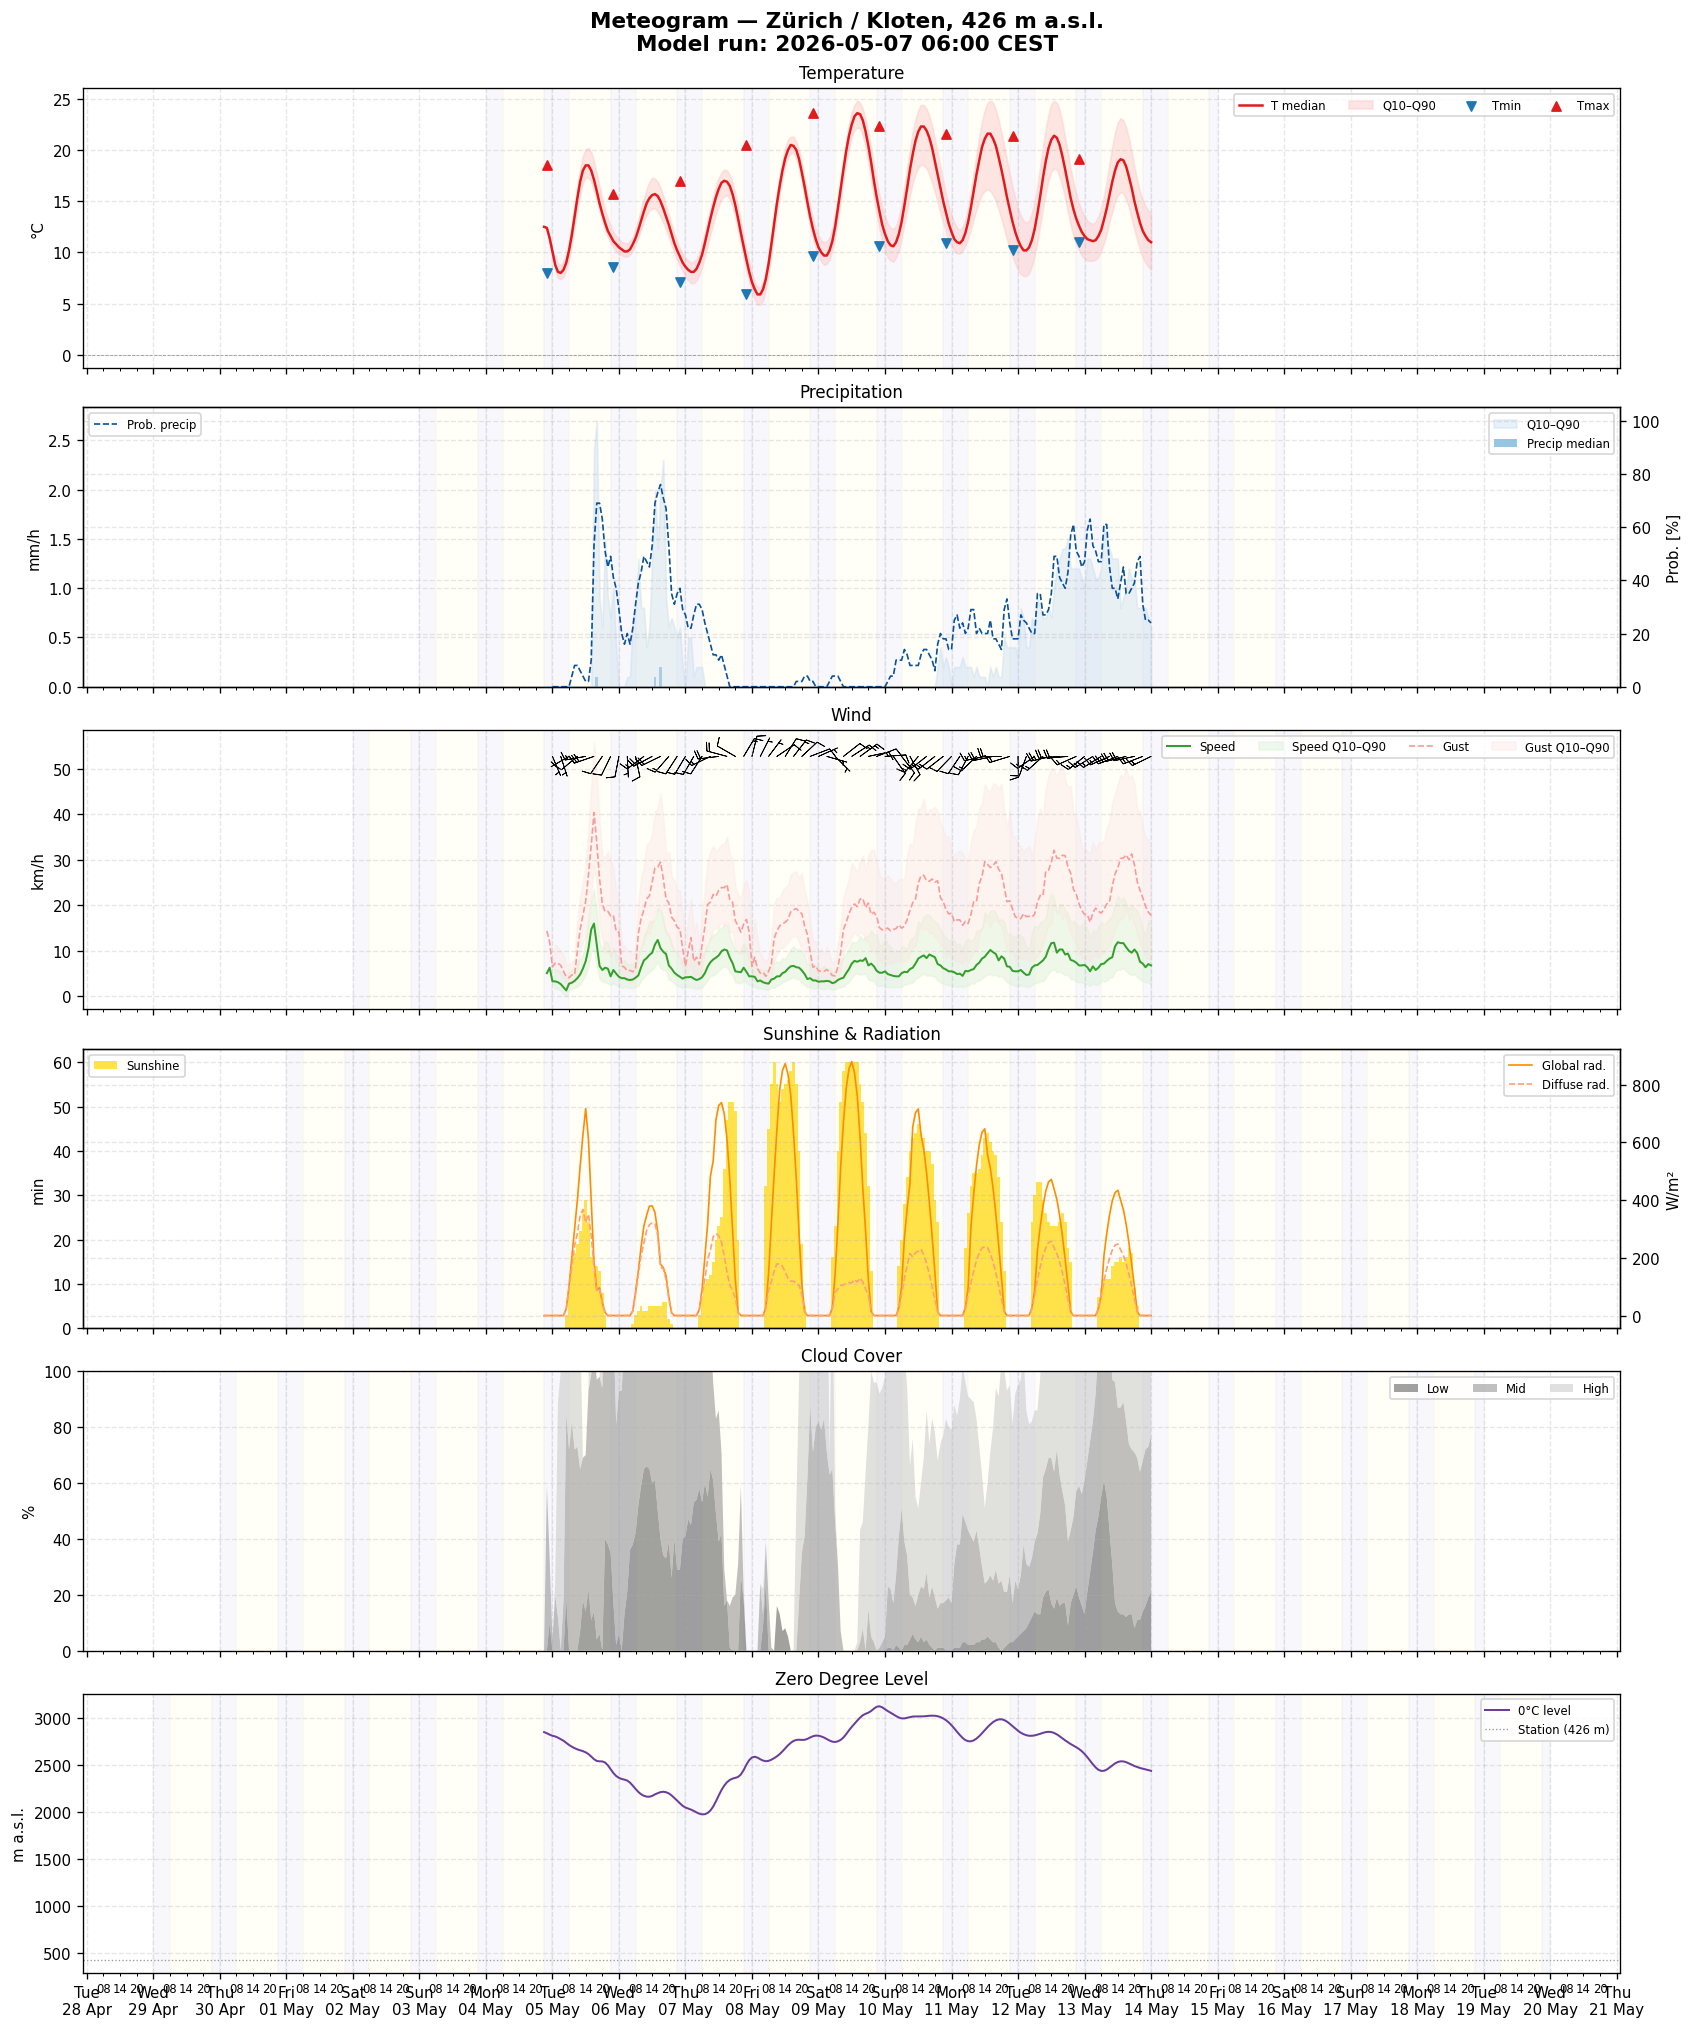

✓ Meteogram rendered


In [21]:
# =============================================================================
# Cell 8 — Plot Assembly
# =============================================================================

# --- Day/night shading helper ---

def add_day_night_shading(ax):
    """Add day/night background shading based on approximate sunrise/sunset."""
    xlim = mdates.num2date(ax.get_xlim())
    start = xlim[0].replace(hour=0, minute=0)
    end = xlim[1]
    
    current = start
    while current < end:
        sunrise = current.replace(hour=6, minute=0)
        sunset = current.replace(hour=21, minute=0)
        next_day = current + timedelta(days=1)
        
        ax.axvspan(current, sunrise, color=COLORS["night_bg"], alpha=0.3, zorder=0)
        ax.axvspan(sunrise, sunset, color=COLORS["day_bg"], alpha=0.3, zorder=0)
        ax.axvspan(sunset, next_day, color=COLORS["night_bg"], alpha=0.3, zorder=0)
        
        current = next_day


def format_time_axis(ax, is_bottom=False):
    """Format x-axis with date/time labels."""
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    
    if is_bottom:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d %b", tz=LOCAL_TZ))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H", tz=LOCAL_TZ))
        ax.tick_params(axis="x", which="minor", labelsize=7)
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter(""))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter(""))


# --- Assemble the meteogram ---

n_panels = len(selected_panels)
fig, axes = plt.subplots(
    n_panels, 1,
    figsize=(14, 2.8 * n_panels),
    sharex=True,
    layout="constrained",
)

# Handle single panel case
if n_panels == 1:
    axes = [axes]

# Plot each panel
for i, panel_name in enumerate(selected_panels):
    ax = axes[i]
    plot_fn = PANEL_FUNCTIONS.get(panel_name)
    if plot_fn:
        plot_fn(ax)
    
    add_day_night_shading(ax)
    format_time_axis(ax, is_bottom=(i == n_panels - 1))

# --- Title ---

poi_name = poi_row.get("point_name", POI)
elev_cols = [c for c in poi_row.index if "elev" in c.lower() or "height" in c.lower() or "alt" in c.lower()]
elev_str = f", {poi_row[elev_cols[0]]:.0f} m a.s.l." if elev_cols else ""

fig.suptitle(
    f"Meteogram — {poi_name}{elev_str}\n"
    f"Model run: {runtime_dt.strftime('%Y-%m-%d %H:%M %Z')}",
    fontsize=13, fontweight="bold",
)

plt.show()

print("✓ Meteogram rendered")